In [2]:
%matplotlib widget
import ipywidgets as widgets
import csv
import time
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Thermal model
total_data = np.genfromtxt('ExperimentData_20260309_141213.csv', delimiter=',')[1:,0:]
T_env = total_data[0,1]
t_model = total_data[:,0]
u_model = total_data[:,3]
t0 = np.argmax(u_model < 0.0)
def thermal_model(T, t, u, T_env, A=350, B=32.75/1.5, t0=0):
    T = B*u*(1-np.exp(-(1/A*(t - 5 - t0)))) + T_env
    T[t < t0] = T_env  # Ensure temperature does not go below ambient
    return T


In [4]:
import control as ct
K = 0.55
tau = 155
plant_tf = ct.tf([K], [tau, 1])
n, d = ct.pade(5, 5)
plant_delay = ct.tf(n, d)
plant_ss = ct.tf2ss(plant_tf*plant_delay)
print(plant_ss.C)

print(1/tau, K/tau)

[[-0.00354839  0.02129032 -0.0596129   0.09538065 -0.08584258  0.03433703]]
0.0064516129032258064 0.0035483870967741938


interactive(children=(FloatSlider(value=1.0, description='A:', max=500.0, min=1.0), FloatSlider(value=0.5, des…

<function __main__.plot_model(A, B)>

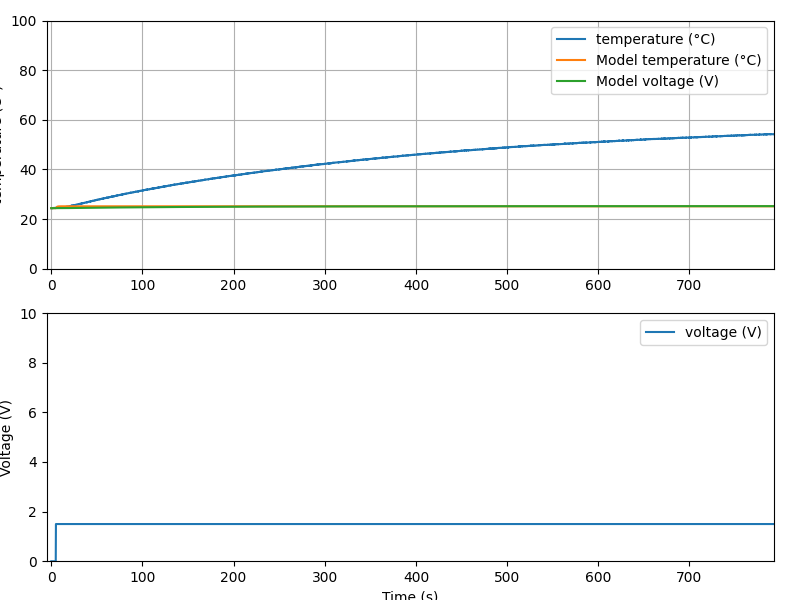

In [5]:
import matplotlib.pyplot as plt
from ipywidgets import interact
plt.ion()
# Create the figure and axes outside the function
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
plt.tight_layout()

# Initialize lines for the plots
line1, = ax1.plot([], [], label='temperature (°C)')
line2, = ax1.plot([], [], label='Model temperature (°C)')
line3, = ax2.plot([], [], label='voltage (V)')
line4, = ax1.plot([], [], label='Model voltage (V)')

# Set labels and limits
ax1.set_ylabel('temperature (C°)')
ax1.set_ylim(0, 100)
ax1.legend()
ax1.grid()
ax1.set_xlim(-5, np.max(total_data[:,0]))

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Voltage (V)')
ax2.set_xlim(-5, np.max(total_data[:,0]))
ax2.set_ylim(0, 10)
ax2.legend()

T_model_solve = ct.forced_response(plant_ss, T=total_data[:, 0], U=total_data[:, 3], X0=np.zeros(np.shape(plant_ss.B)))[1] + T_env
line4.set_data(total_data[:, 0], T_model_solve)

def plot_model(A, B):
    T_model = thermal_model(T_env, t_model, u_model, T_env, A=A, B=B, t0=t0)
    # Update the data for the lines
    line1.set_data(total_data[:, 0], total_data[:, 1])
    line2.set_data(total_data[:, 0], T_model)
    line3.set_data(total_data[:, 0], total_data[:, 3])

    # Redraw the figure
    fig.canvas.draw_idle()


slider_A = widgets.FloatSlider(value=0.1, min=1, max=500, step=0.1, description='A:')
slider_B = widgets.FloatSlider(value=0.5, min=0, max=50, step=0.1, description='B:')

# Use interact with the sliders
interact(plot_model, A=slider_A, B=slider_B)


C:\Users\gertv\AppData\Local\Temp\ipykernel_4812\1954773481.py:6: RuntimeWarning: invalid value encountered in divide
  T_model_solve_i = ct.forced_response(plant_ss, T=total_data[i*t_cut:(i+1)*t_cut, 0], U=total_data[i*t_cut:(i+1)*t_cut, 3], X0=T_previous/plant_ss.B)[1]


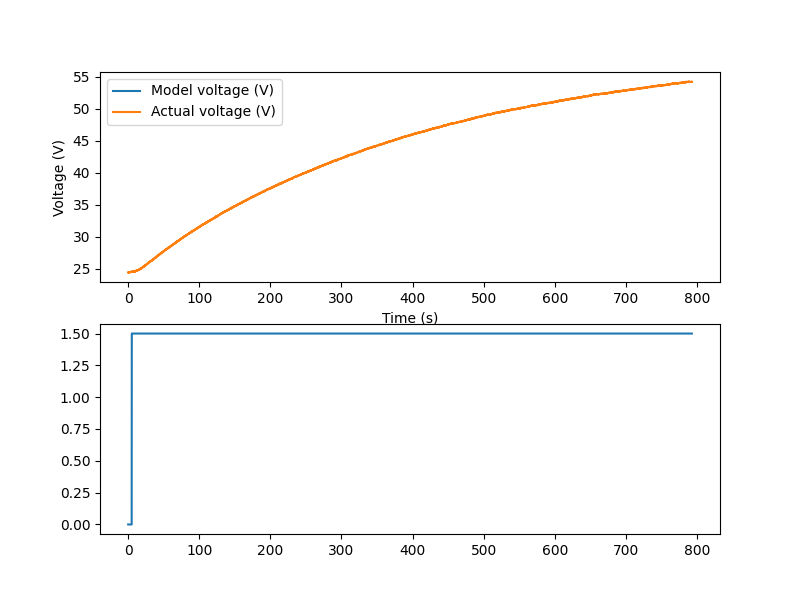

array([nan, nan, nan, ..., nan, nan, nan])

In [ ]:
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
t_cut = 2
T_cat = np.array([])
T_previous = 0
for i in range(len(total_data[:, 0])//t_cut):
    T_model_solve_i = ct.forced_response(plant_ss, T=total_data[i*t_cut:(i+1)*t_cut, 0], U=total_data[i*t_cut:(i+1)*t_cut, 3], X0=T_previous/plant_ss.C)[1]
    T_previous = T_model_solve_i[-1]
    T_cat = np.concatenate((T_cat, T_model_solve_i+T_env))
ax1.plot(total_data[:, 0], T_cat, label='Model voltage (V)')
ax1.plot(total_data[:, 0], total_data[:, 1], label='Actual voltage (V)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Voltage (V)')
ax1.legend()
ax2.plot(total_data[:, 0], total_data[:,3], label='Model temperature (°C)')
plt.show()

T_cat - total_data[:, 3]